In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFECV
from sklearn.base import clone
import scipy.stats as stats
import shap
from sklearn.metrics import roc_auc_score

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

I will be working on Option 1: predicting whether a credit card client will default or not. The dataset has 25 features, which include credit limit, sex, education, marital status, age, past repayment status, past statements, and previous payment amounts. I think there are some features that I will clearly drop, and most of these I will have to process in some way, which I will explore in the EDA section. 

In [3]:
# importing the data 
full_df = pd.read_csv("data/UCI_Credit_Card.csv")
full_df.shape

(30000, 25)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
full_df_features = full_df.drop(columns="default.payment.next.month")
full_df_target = full_df["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(full_df_features, full_df_target, test_size=0.3, random_state=123)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

In [5]:
feature_summary = X_train.describe(include='all')
missing_vals_cols = feature_summary.columns[feature_summary.loc["count"] < len(X_train)].tolist()
feature_summary

# there are no missing values in this dataset 
# all features are numeric, including the categorical ones - definitions are in the kaggle description

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.000000,21000.000000
mean,14962.348238,167880.651429,1.600762,1.852143,1.554000,35.500810,-0.015429,-0.137095,-0.171619,-0.225238,...,47010.414095,43486.610905,40428.518333,38767.202667,5673.585143,5.895027e+03,5311.432286,4774.021381,4751.850095,5237.762190
std,8650.734050,130202.682167,0.489753,0.792961,0.521675,9.212644,1.120465,1.194506,1.196123,1.168556,...,69035.759516,64843.303993,61187.200817,59587.689549,17033.241454,2.180143e+04,18377.997079,15434.136142,15228.193125,18116.846563
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-157264.000000,-50616.000000,-61372.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,7498.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2663.750000,2293.750000,1739.500000,1215.750000,1000.000000,8.200000e+02,390.000000,266.000000,234.000000,110.750000
50%,14960.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,20088.500000,19102.500000,18083.000000,16854.500000,2100.000000,2.007000e+03,1809.500000,1500.000000,1500.000000,1500.000000
75%,22458.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,59895.000000,54763.250000,50491.000000,49253.750000,5007.250000,5.000000e+03,4628.500000,4021.250000,4016.000000,4000.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,855086.000000,891586.000000,927171.000000,961664.000000,873552.000000,1.227082e+06,896040.000000,621000.000000,426529.000000,528666.000000


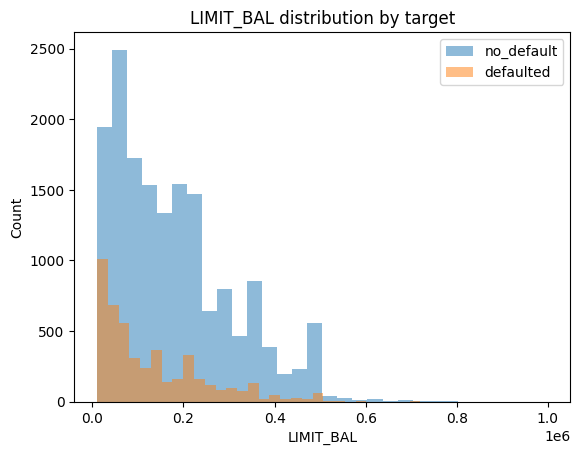

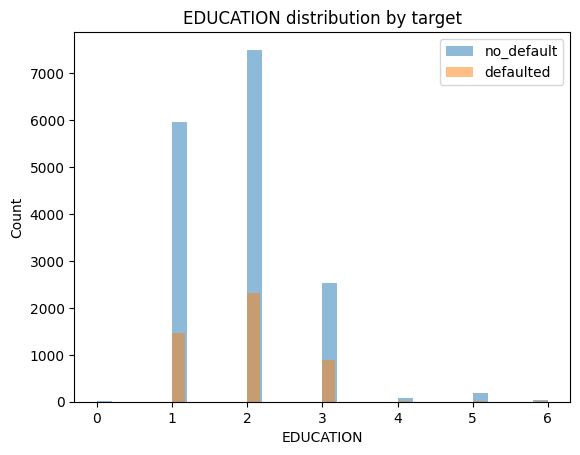

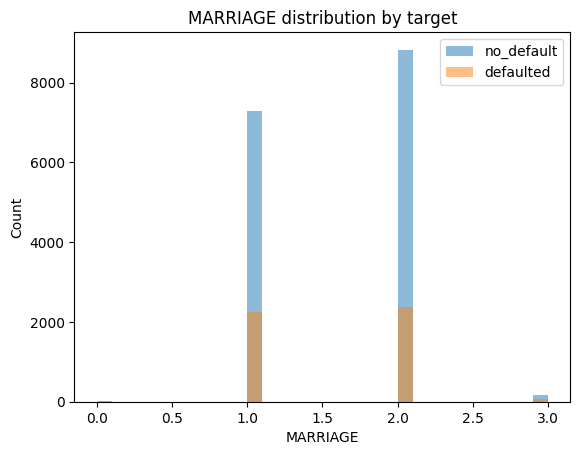

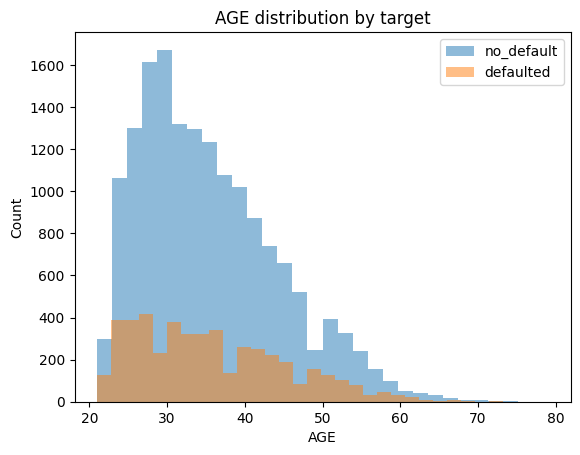

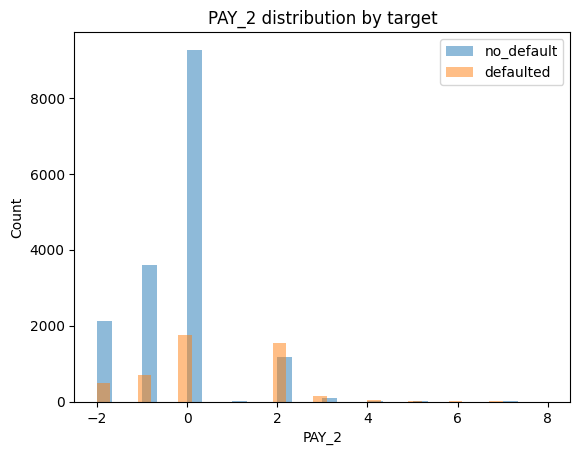

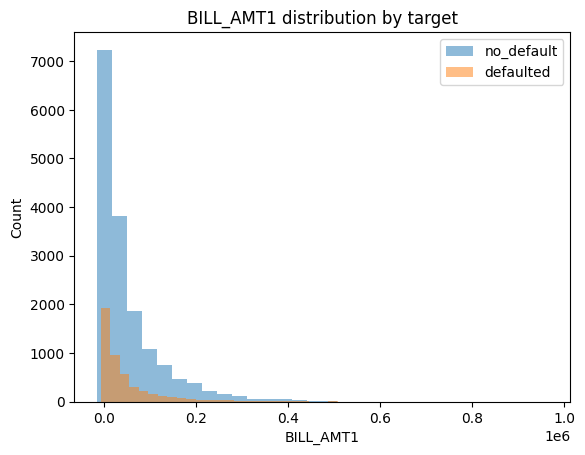

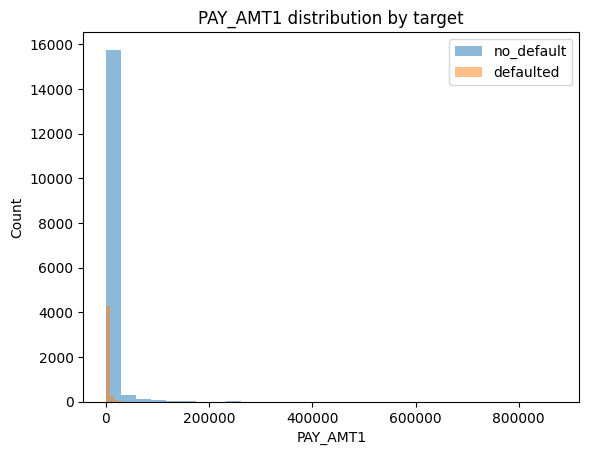

In [6]:
for feature in ["LIMIT_BAL", "EDUCATION", "MARRIAGE", "AGE", "PAY_2", "BILL_AMT1", "PAY_AMT1"]:
    plt.figure()

    plt.hist(
        X_train[y_train == 0][feature],
        bins=30,
        alpha=0.5,
        label="no_default"
    )
    plt.hist(
        X_train[y_train == 1][feature],
        bins=30,
        alpha=0.5,
        label="defaulted"
    )

    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"{feature} distribution by target")
    plt.legend()
    plt.show()

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

from the histograms, maybe the PAY and PAY_AMT columns have slightly different distributions, but other than that, the two classes seem very similar
i would assume that the columns related to payment are going to be the most important in prediction for this target

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

What features might be important and what could we do with them?
* Credit utilization is usually a factor that banks look at for credit score and loans
* The trend of their credit debt might be useful as well (are they accumulating or paying off debt?)
* Payment volatility might be a risk factor for delinquency 
* Credit limit is related to age 
* Drop sex and id (preprocessing)

In [7]:
def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply to the X_train and X_test dataframes 
    """
    
    df = df.copy()

    # credit utilization: clip to circumvent negative BILL_AMT1 or overlimit 
    df['UTIL'] = (df['BILL_AMT1'] / df['LIMIT_BAL']).clip(0, 1)

    # bill amount trend: positive means growing debt 
    bill_matrix = df[['BILL_AMT6', 'BILL_AMT5', 'BILL_AMT4', 'BILL_AMT3', 'BILL_AMT2', 'BILL_AMT1']].values 
    x = np.arange(6) 
    slopes = np.polyfit(x, bill_matrix.T, deg=1)[0] 
    df['BILL_TREND'] = slopes / df['LIMIT_BAL']

    # payment volatility: std of payment amounts 
    df['PAY_VOL'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].std(axis=1)

    # credit limit per age 
    df['LIMIT_PER_AGE'] = df['LIMIT_BAL'] / df['AGE']

    # education: condense 4, 5, 6 values into 4 as they are all unknowns 
    df['EDUCATION'] = df['EDUCATION'].replace({5: 4, 6: 4})

    # marriage: there are some unknown values (0), change to 3 
    df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

    return df

In [8]:
X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

X_train.describe(include='all')

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,UTIL,BILL_TREND,PAY_VOL,LIMIT_PER_AGE
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,14962.348238,167880.651429,1.600762,1.838810,1.558857,35.500810,-0.015429,-0.137095,-0.171619,-0.225238,...,5673.585143,5.895027e+03,5311.432286,4774.021381,4751.850095,5237.762190,0.414113,0.022739,5805.252698,4836.814854
std,8650.734050,130202.682167,0.489753,0.744757,0.521149,9.212644,1.120465,1.194506,1.196123,1.168556,...,17033.241454,2.180143e+04,18377.997079,15434.136142,15228.193125,18116.846563,0.386892,0.063805,14900.672029,3719.280253
min,1.000000,10000.000000,1.000000,0.000000,1.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-0.462580,0.000000,161.290323
25%,7498.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1000.000000,8.200000e+02,390.000000,266.000000,234.000000,110.750000,0.022372,-0.005874,611.170481,1836.734694
50%,14960.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,2100.000000,2.007000e+03,1809.500000,1500.000000,1500.000000,1500.000000,0.314359,0.001564,1419.282929,4000.000000
75%,22458.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,5007.250000,5.000000e+03,4628.500000,4021.250000,4016.000000,4000.000000,0.828188,0.038197,4114.154839,6896.551724
max,30000.000000,1000000.000000,2.000000,4.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,873552.000000,1.227082e+06,896040.000000,621000.000000,426529.000000,528666.000000,1.000000,1.166823,485168.444748,26785.714286


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

Mostly numeric columns. Education and the PAY columns are already ordered, so we will just apply a StandardScaler to them. Marriage is the only categorical column, and we will drop id and sex. 

In [9]:
numeric_cols = ["LIMIT_BAL", "EDUCATION", "AGE", 
                "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6", 
                "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6", 
                "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
                "UTIL", "BILL_TREND", "PAY_VOL", "LIMIT_PER_AGE"]
categorical_cols = ["MARRIAGE"]
drop_cols = ["ID", "SEX"]
target = "default.payment.next.month"

In [10]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="if_binary", handle_unknown="ignore")

In [11]:
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_cols),
    (categorical_transformer, categorical_cols),
    ('drop', drop_cols)
)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

Using ROC-AUC to score the dummy classifier. The accuracy I observed here was about 0.777. We see that we get the expected AUC score of 0.5, as the dummy classifier is by default going with the most_frequent strategy. 

In [12]:
dummy_model = DummyClassifier(random_state=123)
dummy_pipe = make_pipeline(preprocessor, dummy_model)
dummy_df = pd.DataFrame(cross_validate(dummy_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True))
dummy_df

,fit_time,score_time,test_score,train_score
0,0.034799,0.008385,0.5,0.5
1,0.018945,0.006962,0.5,0.5
2,0.019309,0.007045,0.5,0.5
3,0.018996,0.007006,0.5,0.5
4,0.021114,0.008432,0.5,0.5


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

Let's try logistic regression - maybe the coefficients will also be able to tell us something about the dataset afterwards too! 

In [13]:
# taking this method provided from HW3

def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [14]:
lr_model = LogisticRegression(random_state=123, max_iter=1000)
lr_pipe = make_pipeline(preprocessor, lr_model)

lr_default_results = pd.DataFrame(mean_std_cross_val_scores(lr_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True))
lr_default_results.T

,fit_time,score_time,test_score,train_score
0,0.048 (+/- 0.005),0.008 (+/- 0.001),0.731 (+/- 0.010),0.733 (+/- 0.002)


In [15]:
param_grid = {"logisticregression__C": np.logspace(-3, 3, 7)}
grid_search = GridSearchCV(lr_pipe, param_grid=param_grid, scoring="roc_auc", cv=5, n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=123))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': array([1.e-03...e+02, 1.e+03])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [16]:
lr_best_C = 100
lr_model = LogisticRegression(random_state=123, max_iter=1000, C=lr_best_C)
lr_pipe = make_pipeline(preprocessor, lr_model)

lr_default_results = pd.DataFrame(mean_std_cross_val_scores(lr_pipe, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True))
lr_default_results.T

,fit_time,score_time,test_score,train_score
0,0.051 (+/- 0.009),0.008 (+/- 0.000),0.731 (+/- 0.010),0.733 (+/- 0.002)


Between the default C value and the best C value, there is literally no difference in performance. This might be the limit of our linear model. 

In [17]:
feature_names = grid_search.best_estimator_['columntransformer'].get_feature_names_out()
coefficients = grid_search.best_estimator_['logisticregression'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.sort_values(by=["coefficient"], ascending=False)

,feature,coefficient
23,standardscaler__PAY_VOL,0.947388
3,standardscaler__PAY_0,0.605753
0,standardscaler__LIMIT_BAL,0.284845
10,standardscaler__BILL_AMT2,0.189286
11,standardscaler__BILL_AMT3,0.129759
5,standardscaler__PAY_3,0.111419
4,standardscaler__PAY_2,0.102128
7,standardscaler__PAY_5,0.049073
8,standardscaler__PAY_6,0.043842
14,standardscaler__BILL_AMT6,0.042766


Seems like PAY_VOL, PAY, and PAY_AMT are important to the logistic regression model. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

I'm going to try Random Forest, XGBoost, and LightGBM. Full disclosure, I wanted to try SVM with RBF kernel initially, but it just took way too long to train. 

In [18]:
models = {
    "Random Forest": RandomForestClassifier(random_state=123, n_jobs=-1, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=123, n_jobs=-1, eval_metric="logloss", n_estimators=100),
    "LightGBM": LGBMClassifier(random_state=123, n_jobs=-1, n_estimators=100)
}

cv_results = {}

for name, model in models.items():
    pipeline = make_pipeline(preprocessor, clone(model))
    cv_results[name] = pd.DataFrame(mean_std_cross_val_scores(pipeline, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True, n_jobs=-1))

cv_results

{'Random Forest':                              0
 fit_time     2.451 (+/- 0.049)
 score_time   0.086 (+/- 0.029)
 test_score   0.764 (+/- 0.004)
 train_score  1.000 (+/- 0.000),
 'XGBoost':                              0
 fit_time     0.947 (+/- 0.012)
 score_time   0.019 (+/- 0.001)
 test_score   0.756 (+/- 0.009)
 train_score  0.974 (+/- 0.002),
 'LightGBM':                              0
 fit_time     0.647 (+/- 0.047)
 score_time   0.031 (+/- 0.015)
 test_score   0.778 (+/- 0.006)
 train_score  0.908 (+/- 0.003)}

All of the ensemble methods very clearly overfit on the training dataset. However, we did see better test performance from all of them compared to the linear model. The best performing default model was LightGBM, with a cross validation AUC of 0.778. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

We will ue RFECV to find relevant features. Since we can only do this for one model at a time, let's apply this to only the Random Forest model, and we can use the features it found important for all three models afterwards. 

In [19]:
rf_model = clone(models["Random Forest"])
rfecv = RFECV(estimator=rf_model, cv=5, scoring="roc_auc", min_features_to_select=1, n_jobs=-1)
feature_selection_pipe = make_pipeline(preprocessor, rfecv)
feature_selection_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('rfecv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [20]:
feature_names = feature_selection_pipe['columntransformer'].get_feature_names_out()
selected_mask = feature_selection_pipe['rfecv'].support_
selected_features = feature_names[selected_mask]
selected_features

array(['standardscaler__LIMIT_BAL', 'standardscaler__EDUCATION',
       'standardscaler__AGE', 'standardscaler__PAY_0',
       'standardscaler__PAY_2', 'standardscaler__PAY_3',
       'standardscaler__PAY_4', 'standardscaler__PAY_5',
       'standardscaler__PAY_6', 'standardscaler__BILL_AMT1',
       'standardscaler__BILL_AMT2', 'standardscaler__BILL_AMT3',
       'standardscaler__BILL_AMT4', 'standardscaler__BILL_AMT5',
       'standardscaler__BILL_AMT6', 'standardscaler__PAY_AMT1',
       'standardscaler__PAY_AMT2', 'standardscaler__PAY_AMT3',
       'standardscaler__PAY_AMT4', 'standardscaler__PAY_AMT5',
       'standardscaler__PAY_AMT6', 'standardscaler__UTIL',
       'standardscaler__BILL_TREND', 'standardscaler__PAY_VOL',
       'standardscaler__LIMIT_PER_AGE', 'onehotencoder__MARRIAGE_1',
       'onehotencoder__MARRIAGE_2'], dtype=object)

It pretty much selected all the features - it isn't worth running again to check model performance, since there aren't any unimportant features to remove. I did try running the code to add RFECV into the pipeline and check resultant performance, but I gave up after 5 minutes of runtime. Realistically we shouldn't see much difference in the model performance since we're literally only dropping one feature. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

We will use RandomizedSearchCV to tune one hyperparameter for both Random Forest and XGBoost, and we will tune 2 hyperparameters for LightGBM. We are cutting down n_iter to 10 and cv to 3 to cut down on processing time, as my computer is not having a good time running the code. 

In [21]:
param_grids = {
    "Random Forest": {
        "randomforestclassifier__max_depth": [None, 10, 20, 30],
    },
    "XGBoost": {
        "xgbclassifier__learning_rate": stats.loguniform(0.01, 0.3),
    },
    "LightGBM": {
        "lgbmclassifier__num_leaves": stats.randint(20, 150),
        "lgbmclassifier__learning_rate": stats.loguniform(0.01, 0.3),
        "lgbmclassifier__max_depth": stats.randint(3, 10),
    }
}

best_estimators = {}

for name, model in models.items():
    ho_pipe = make_pipeline(preprocessor, clone(model))

    search = RandomizedSearchCV(ho_pipe, param_distributions=param_grids[name], n_iter=20, scoring="roc_auc", cv=5, random_state=123, n_jobs=-1)
    search.fit(X_train, y_train)
    best_estimators[name] = search.best_estimator_

c:\Users\xenon\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[LightGBM] [Info] Number of positive: 4688, number of negative: 16312
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001941 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4290
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.223238 -> initscore=-1.246895
[LightGBM] [Info] Start training from score -1.246895
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [22]:
cv_results = {}

for name, estimator in best_estimators.items():
    cv_results[name] = pd.DataFrame(mean_std_cross_val_scores(estimator, X_train, y_train, cv=5, scoring="roc_auc", return_train_score=True, n_jobs=-1))

cv_results

{'Random Forest':                              0
 fit_time     1.324 (+/- 0.237)
 score_time   0.160 (+/- 0.081)
 test_score   0.783 (+/- 0.006)
 train_score  0.884 (+/- 0.002),
 'XGBoost':                              0
 fit_time     0.626 (+/- 0.006)
 score_time   0.019 (+/- 0.000)
 test_score   0.782 (+/- 0.006)
 train_score  0.848 (+/- 0.002),
 'LightGBM':                              0
 fit_time     0.625 (+/- 0.068)
 score_time   0.020 (+/- 0.005)
 test_score   0.784 (+/- 0.007)
 train_score  0.830 (+/- 0.002)}

Hyperparameter optimization improved the results slightly. The best performing model, LightGBM, had its AUC increase from 0.778 to 0.784. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

c:\Users\xenon\miniforge3\envs\cpsc330\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


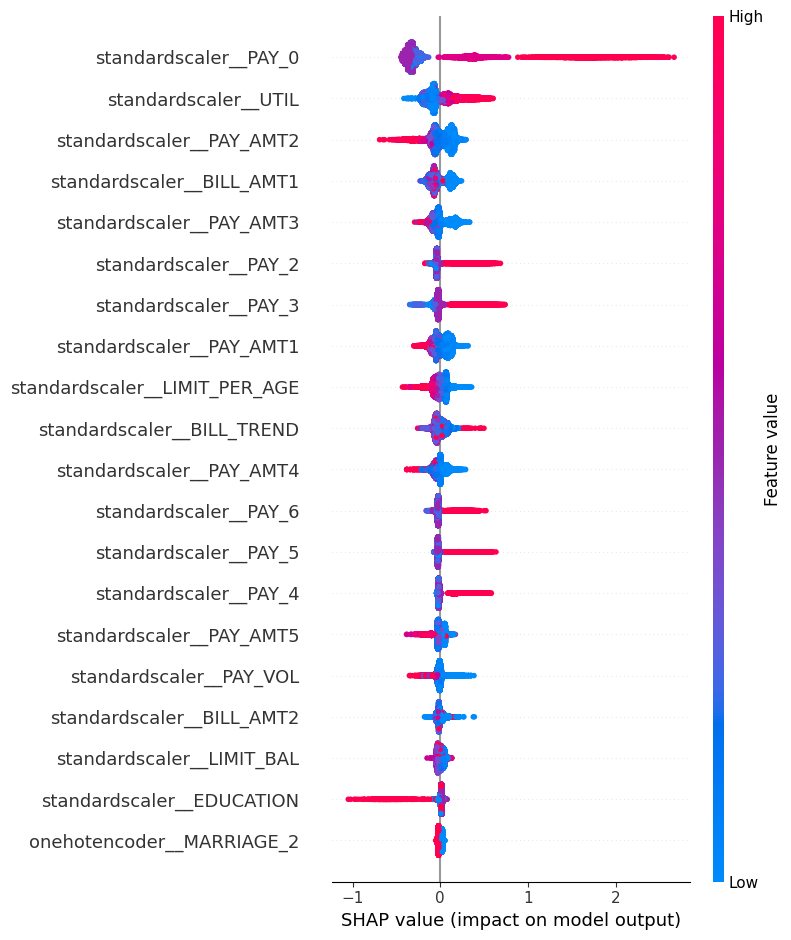

In [23]:
lgbm_preprocessor = best_estimators["LightGBM"]["columntransformer"]
lgbm_model = best_estimators["LightGBM"]["lgbmclassifier"]
feature_names = lgbm_preprocessor.get_feature_names_out()

X_train_transformed = lgbm_preprocessor.transform(X_train)

explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)

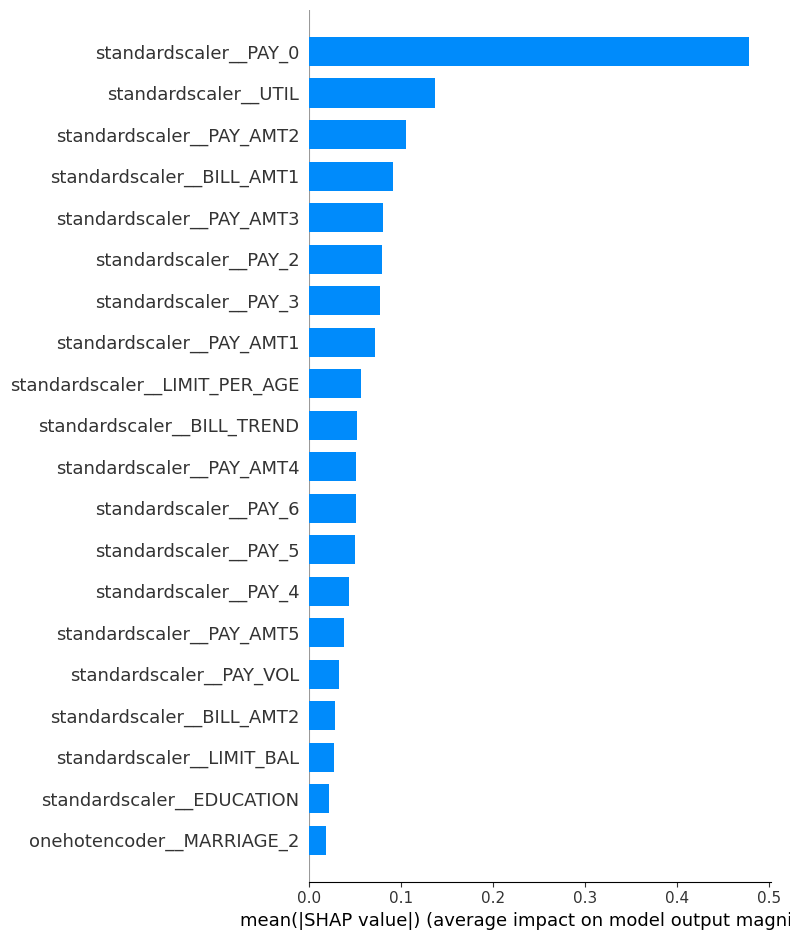

In [24]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names, plot_type="bar")

Seems like PAY_0 is extremely important for prediction (high PAY_0 corresponds with default, and low PAY_0 with no default), and there is some dependence on UTIL, recent PAY_AMTs, PAYs and BILL_AMTs. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

In [25]:
X_test_transformed = lgbm_preprocessor.transform(X_test)
pred_probs = lgbm_model.predict_proba(X_test_transformed)[:, 1]
test_auc = roc_auc_score(y_test, pred_probs)
test_auc

c:\Users\xenon\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.783956173034344

Our final test score here is 0.784, which is exactly the same as what we saw in the cross validation, which seems to indicate that the model is working properly and generalizing to unseen data. Doesn't seem like we are encountering any optimization bias here. 

In [26]:
pred_labels = (pred_probs >= 0.5).astype(int)
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

correct_default    = np.where((pred_labels == 1) & (y_test == 1))[0][0]
correct_nondefault = np.where((pred_labels == 0) & (y_test == 0))[0][0]

shap.initjs()

c:\Users\xenon\miniforge3\envs\cpsc330\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [27]:
shap.force_plot(explainer.expected_value, shap_values[correct_default], X_test_transformed[correct_default], feature_names=feature_names)

In [28]:
shap.force_plot(explainer.expected_value, shap_values[correct_nondefault], X_test_transformed[correct_nondefault], feature_names=feature_names)

From the SHAP force plots on both a positive and negative target example, we once again see that PAY_0 plays a very big role in predictions. Many of the other features seem to be used as well, but not to the same extent as PAY_0. 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

The best performing model was the **optimized LightGBM model**, with num_leaves = 52, lr = 0.051, and max_depth = 4. This saw a cross-validation **ROC-AUC score of 0.784**, and it got the exact same score on the test data. 

From our SHAP analysis, the most impactful features were PAY_0, UTIL, PAY_AMT2, BILL_AMT1, and PAY_AMT3. 

The optimized ensemble tree methods all seemed to do quite well, and didn't take a super long time to train. For better performance, I probably could increase the number of hyperparameters to optimize for, or the number of iterations to run RandomizedSearchCV with (it would just take much longer, and I didn't think it was worth pursuing for this assignment). I also could've played around more with the feature engineering; credit utilization ended up being very important for the model's predictions, which I was happy to see, but the others were not incredibly important. One last thing I could do would be to iterate on the engineered features and preprocessing after seeing the SHAP values - maybe I could've condensed the older PAY_AMT, BILL_AMT, etc fields, and maybe found better features to add into the model to improve predictions. 

In [29]:
results_df = pd.DataFrame([
    ("DummyClassifier (most frequent)", "—", 0.500),
    ("Logistic Regression", "C=100", 0.731),
    ("Random Forest (default)", "—",  0.764),
    ("XGBoost (default)", "—", 0.756),
    ("LightGBM (default)", "—", 0.778),
    ("Random Forest (tuned)", "max_depth=10", 0.783),
    ("XGBoost (tuned)", "learning_rate=0.065", 0.782),
    ("LightGBM (tuned)",  "num_leaves=52, lr=0.051, max_depth=4", 0.784),
], columns=["Model", "Key Hyperparameters", "CV ROC-AUC"])

results_df = results_df.sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Key Hyperparameters,CV ROC-AUC
0,LightGBM (tuned),"num_leaves=52, lr=0.051, max_depth=4",0.784
1,Random Forest (tuned),max_depth=10,0.783
2,XGBoost (tuned),learning_rate=0.065,0.782
3,LightGBM (default),—,0.778
4,Random Forest (default),—,0.764
5,XGBoost (default),—,0.756
6,Logistic Regression,C=100,0.731
7,DummyClassifier (most frequent),—,0.500


<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

Running hyperparameter optimization takes a really long time! On my first pass on this assignment, leaving the default n_estimators for each of the nonlinear models, it spent upwards of 45 minutes without completing. Also, I underestimated the importance of feature engineering up until I saw how much impact it had on this model here; definitely seemed like it was worth doing. 

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)